# AdSavant — Instagram Engagement Prediction Pipeline (v3 — Enhanced)

**Module:** 6BUIS020W — Business Information Systems Final Project  
**Purpose:** Train and evaluate a multimodal ML model that predicts Instagram engagement rate for Sri Lankan fashion SMEs.  

---

## What's New in v3 (Accuracy Improvements)

| Enhancement | Description |
|-------------|-------------|
| CLIP Embeddings | Replaced ResNet50 with OpenAI CLIP (ViT-B/32) — understands fashion & social media content |
| Multi-Crop TTA | Averages embeddings across 5 augmented views per image for robust representations |
| Image–Caption Similarity | CLIP cross-modal similarity as a powerful engagement signal |
| Image Metadata | Brightness, contrast, colorfulness, aspect ratio — interpretable low-noise features |
| Expanded Text Features | Restored hashtag_count, cta_count, sentiment — proven engagement correlates |
| Dual-Head Training | Both regression (ER prediction) AND classification (Low/Avg/High) with SMOTE |
| Broader Model Zoo | Added SVR, LightGBM alongside existing candidates |

> **Note:** This notebook is designed for Google Colab with a free-tier GPU/CPU runtime.


In [24]:
import numpy, sklearn, pandas, scipy, joblib

print("numpy:", numpy.__version__)
print("sklearn:", sklearn.__version__)
print("pandas:", pandas.__version__)
print("scipy:", scipy.__version__)
print("joblib:", joblib.__version__)

numpy: 1.26.4
sklearn: 1.8.0
pandas: 3.0.2
scipy: 1.17.1
joblib: 1.5.3


---
## 1. Setup & Configuration

In [25]:
# ============================================================
# 1.1  Install additional dependencies
# ============================================================
!pip install -q shap==0.45.1 textblob==0.18.0 emoji==2.14.0 joblib pillow requests
!pip install -q open-clip-torch lightgbm imbalanced-learn

# TextBlob corpora (for sentiment analysis)
!python -m textblob.download_corpora lite

Finished.


[nltk_data] Downloading package brown to
[nltk_data]     C:\Users\chana\AppData\Roaming\nltk_data...
[nltk_data]   Package brown is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\chana\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\chana\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\chana\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


In [26]:
# ============================================================
# 1.2  Imports
# ============================================================
import os
import re
import warnings
import hashlib
from pathlib import Path
from typing import List, Tuple, Optional

import numpy as np

if not hasattr(np, "obj2sctype"):
    np.obj2sctype = lambda obj: np.dtype(obj).type

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
from textblob import TextBlob
import emoji

# Image processing
from PIL import Image, ImageStat
import requests
from io import BytesIO

# Deep Learning — CLIP embeddings (replaces ResNet50)
import torch
import open_clip

# Scikit-learn
from sklearn.model_selection import (
    StratifiedKFold,
    RepeatedKFold,
    RepeatedStratifiedKFold,
    cross_val_score,
    GridSearchCV,
    train_test_split,
)
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    LabelEncoder,
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error,
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
)
from sklearn.decomposition import PCA

# Models — Regression
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    StackingRegressor,
    RandomForestClassifier,
    GradientBoostingClassifier,
    StackingClassifier,
)
from sklearn.svm import SVR, SVC
import xgboost as xgb
import lightgbm as lgb

# SMOTE for class balancing
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Explainability
import shap

# Serialization
import joblib

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

# ============================================================
# 1.3  Reproducibility
# ============================================================
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

print("✅ All imports successful (including CLIP, LightGBM, SMOTE).")

✅ All imports successful (including CLIP, LightGBM, SMOTE).


In [27]:
# ============================================================
# 1.4  Configuration Constants
# ============================================================
class Config:
    """Central configuration for the entire pipeline."""

    # Paths
    DATA_PATH: str = "adsavant_-_dataset.xlsx"
    MODEL_OUTPUT_DIR: str = "./artifacts"
    IMAGE_CACHE_DIR: str = "./image_cache"

    # Feature extraction — CLIP replaces ResNet50
    IMAGE_SIZE: Tuple[int, int] = (224, 224)
    CLIP_MODEL: str = "ViT-B-32"
    CLIP_PRETRAINED: str = "laion2b_s34b_b79k"
    CLIP_FEATURE_DIM: int = 512  # CLIP ViT-B/32 output dim (vs 2048 for ResNet)

    # Multi-crop TTA settings
    N_AUGMENT_VIEWS: int = 5  # Number of augmented views per image

    # Engagement thresholds (from AdSavant spec)
    ER_HIGH_THRESHOLD: float = 5.0
    ER_AVG_THRESHOLD: float = 2.0

    # Training
    TEST_SIZE: float = 0.20
    CV_FOLDS: int = 5
    RANDOM_STATE: int = RANDOM_STATE

    # Log transform target to handle right-skew
    LOG_TRANSFORM_TARGET: bool = True


config = Config()
os.makedirs(config.MODEL_OUTPUT_DIR, exist_ok=True)
os.makedirs(config.IMAGE_CACHE_DIR, exist_ok=True)
print(f"✅ Config loaded. CLIP model: {config.CLIP_MODEL}")

✅ Config loaded. CLIP model: ViT-B-32


---
## 2. Data Ingestion & Cleaning

In [28]:
# ============================================================
# 2.1  Load raw data
# ============================================================
config.DATA_PATH = r'C:\Users\chana\OneDrive\Desktop\ML Cw\adsavant-app\Data Sets\adsavant - dataset.xlsx'

raw_df = pd.read_excel(config.DATA_PATH)
print(f"Raw dataset: {raw_df.shape[0]} rows × {raw_df.shape[1]} columns")
raw_df.head()
print(f"Excel rows detected: {len(raw_df)}")
print(f"Empty rows dropped? {raw_df.isnull().all(axis=1).sum()}")

Raw dataset: 148 rows × 10 columns
Excel rows detected: 148
Empty rows dropped? 0


In [29]:
# ============================================================
# 2.2  Schema normalization
# ============================================================
def clean_column_names(df: pd.DataFrame) -> pd.DataFrame:
    """Standardize column names to snake_case."""
    rename_map = {
        " brand Type": "brand_type",
        "brand": "brand",
        "img ID ": "img_id",
        "image_url": "image_url",
        "caption": "caption",
        "caption legnth ": "caption_length",
        "like ": "likes",
        "comments": "comments",
        "followers": "followers",
        "engagment rate": "engagement_rate",
    }
    return df.rename(columns=rename_map)


df = clean_column_names(raw_df.copy())

# Normalize categorical values (strip whitespace, lowercase)
df["brand_type"] = df["brand_type"].str.strip().str.lower()
df["brand"] = df["brand"].str.strip().str.lower()
print("total columns:", len(df))
print("Cleaned columns:", df.columns.tolist())
print(f"Brand types: {df['brand_type'].unique().tolist()}")

total columns: 148
Cleaned columns: ['brand_type', 'brand', 'img_id', 'image_url', 'caption', 'caption_length', 'likes', 'comments', 'followers', 'engagement_rate']
Brand types: ['sports wear', 'casual wear', 'ethnic wear', 'ethnic']


In [30]:
# ============================================================
# 2.3  Handle missing values
# ============================================================
print("Missing values before cleaning:")
print(df.isnull().sum())

# Fill missing captions with empty string
df["caption"] = df["caption"].fillna("")

# Fill missing comments with 0 (likely means zero comments)
df["comments"] = df["comments"].fillna(0).astype(int)

# Recalculate caption_length for consistency
df["caption_length"] = df["caption"].str.len()

print("\nMissing values after cleaning:")
print(df.isnull().sum())
print(f"\n✅ Clean dataset: {df.shape[0]} rows")

Missing values before cleaning:
brand_type          0
brand              21
img_id              0
image_url           0
caption             2
caption_length      0
likes               0
comments           32
followers           0
engagement_rate     0
dtype: int64

Missing values after cleaning:
brand_type          0
brand              21
img_id              0
image_url           0
caption             0
caption_length      0
likes               0
comments            0
followers           0
engagement_rate     0
dtype: int64

✅ Clean dataset: 148 rows


In [31]:
# ============================================================
# 2.4  Verify engagement rate calculation
# ============================================================
# ER = (likes + comments) / followers * 100
df["er_recalculated"] = (df["likes"] + df["comments"]) / df["followers"] * 100
df["er_diff"] = abs(df["engagement_rate"] - df["er_recalculated"])

print(f"Max ER difference from recalculation: {df['er_diff'].max():.6f}")
print(f"Mean ER difference: {df['er_diff'].mean():.6f}")

# Use recalculated for consistency
df["engagement_rate"] = df["er_recalculated"]
df.drop(columns=["er_recalculated", "er_diff"], inplace=True)
print("\n✅ Engagement rate verified and standardized.")

Max ER difference from recalculation: 1.719787
Mean ER difference: 0.011620

✅ Engagement rate verified and standardized.


---
## 3. Exploratory Data Analysis

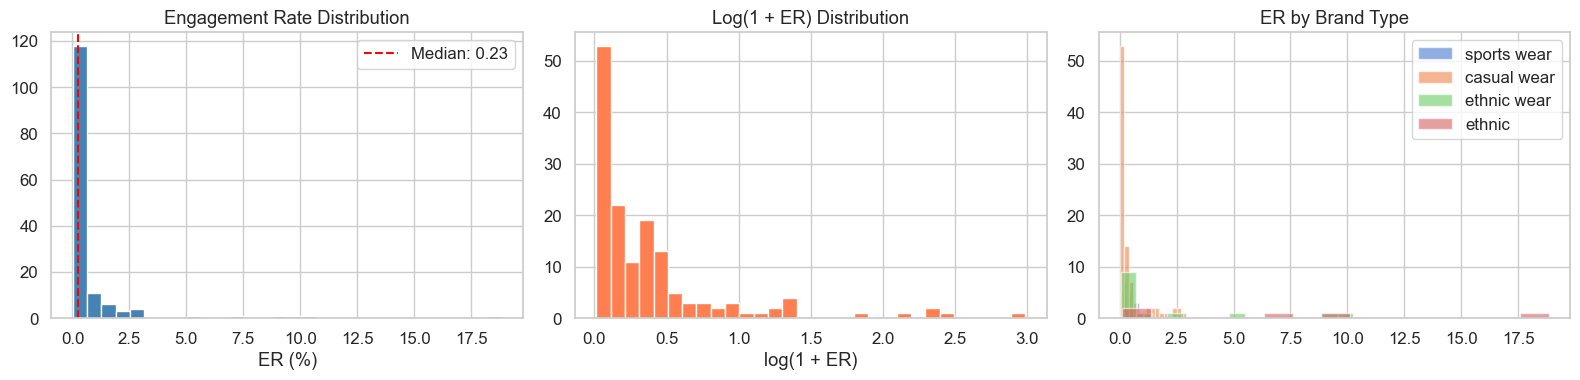


📊 The target is heavily right-skewed — log transform will help the model.


In [32]:
# ============================================================
# 3.1  Target variable distribution
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Raw distribution
axes[0].hist(df["engagement_rate"], bins=30, color="steelblue", edgecolor="white")
axes[0].set_title("Engagement Rate Distribution")
axes[0].set_xlabel("ER (%)")
axes[0].axvline(df["engagement_rate"].median(), color="red", ls="--", label=f'Median: {df["engagement_rate"].median():.2f}')
axes[0].legend()

# Log-transformed
log_er = np.log1p(df["engagement_rate"])
axes[1].hist(log_er, bins=30, color="coral", edgecolor="white")
axes[1].set_title("Log(1 + ER) Distribution")
axes[1].set_xlabel("log(1 + ER)")

# By brand type
for bt in df["brand_type"].unique():
    subset = df[df["brand_type"] == bt]["engagement_rate"]
    axes[2].hist(subset, bins=15, alpha=0.6, label=bt)
axes[2].set_title("ER by Brand Type")
axes[2].legend()

plt.tight_layout()
plt.savefig(f"{config.MODEL_OUTPUT_DIR}/eda_target_distribution.png", dpi=150)
plt.show()
print("\n📊 The target is heavily right-skewed — log transform will help the model.")

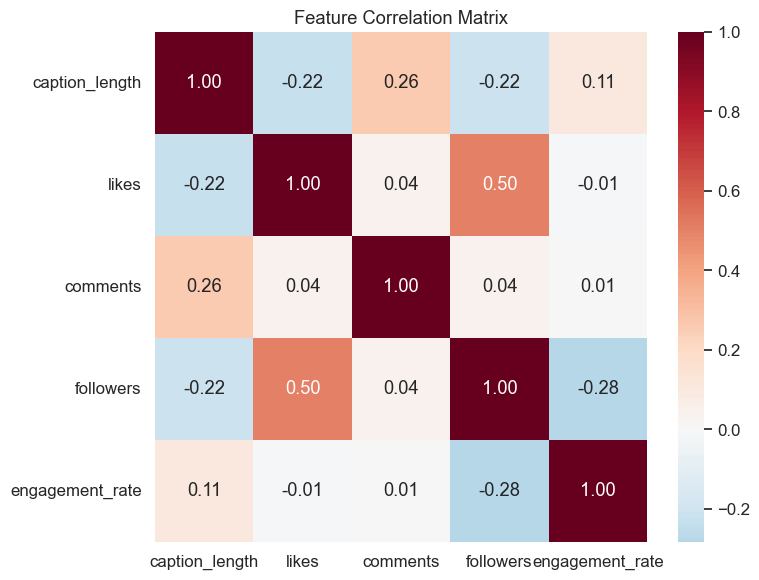

In [33]:
# ============================================================
# 3.2  Feature correlations
# ============================================================
numeric_features = ["caption_length", "likes", "comments", "followers", "engagement_rate"]

fig, ax = plt.subplots(figsize=(8, 6))
corr_matrix = df[numeric_features].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Feature Correlation Matrix")
plt.tight_layout()
plt.savefig(f"{config.MODEL_OUTPUT_DIR}/eda_correlation.png", dpi=150)
plt.show()

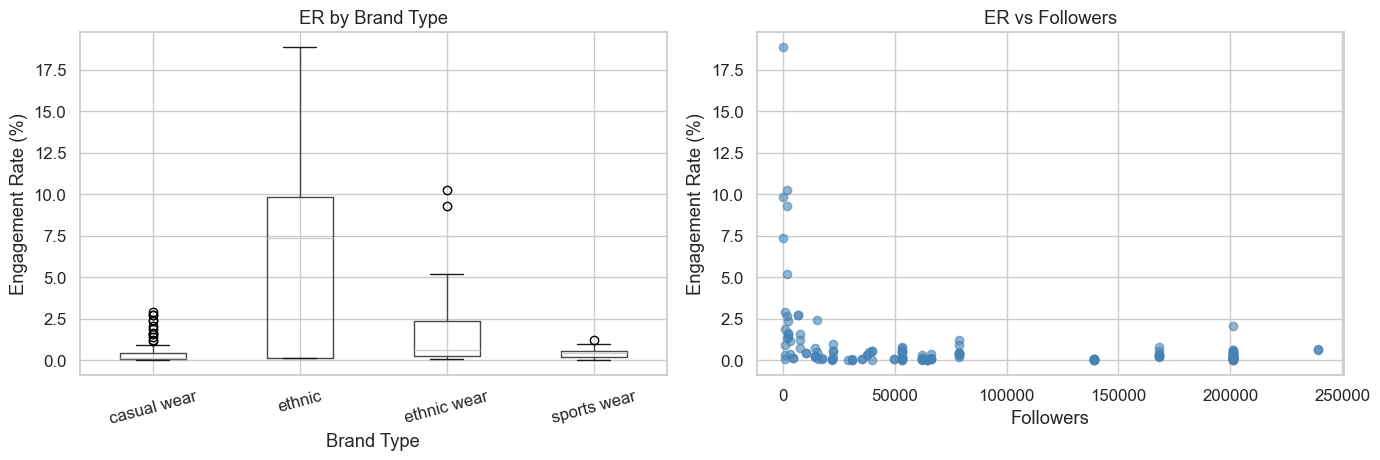


📊 Key insight: Smaller accounts have higher ER — classic Instagram pattern.
   This means followers (or log_followers) will be a strong predictor.


In [34]:
# ============================================================
# 3.3  Engagement by brand and brand type
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By brand type
df.boxplot(column="engagement_rate", by="brand_type", ax=axes[0])
axes[0].set_title("ER by Brand Type")
axes[0].set_xlabel("Brand Type")
axes[0].set_ylabel("Engagement Rate (%)")
plt.sca(axes[0])
plt.xticks(rotation=15)

# ER vs Followers (key relationship)
axes[1].scatter(df["followers"], df["engagement_rate"], alpha=0.6, c="steelblue")
axes[1].set_title("ER vs Followers")
axes[1].set_xlabel("Followers")
axes[1].set_ylabel("Engagement Rate (%)")

fig.suptitle("")
plt.tight_layout()
plt.savefig(f"{config.MODEL_OUTPUT_DIR}/eda_brand_analysis.png", dpi=150)
plt.show()

print("\n📊 Key insight: Smaller accounts have higher ER — classic Instagram pattern.")
print("   This means followers (or log_followers) will be a strong predictor.")

---
## 4. Feature Engineering

We build four feature groups (expanded from v2):
1. **Text features** — NLP analysis of captions (expanded: +hashtags, +CTA, +sentiment)
2. **Image embeddings** — CLIP ViT-B/32 with multi-crop TTA (replaces ResNet50)
3. **Image–caption similarity** — CLIP cross-modal alignment score (NEW)
4. **Image metadata** — brightness, contrast, colorfulness, aspect ratio (NEW)
5. **Metadata features** — brand type, followers, follower tier

### 4.1 Text Feature Extraction

In [35]:
# ============================================================
# 4.1  Text / Caption Feature Engineering
# ============================================================
class TextFeatureExtractor:
    """Extract NLP features from Instagram captions."""

    # Common high-engagement CTA patterns in fashion/Instagram
    CTA_PATTERNS = [
        r"\bshop\b", r"\bbuy\b", r"\blink in bio\b", r"\bavailable\b",
        r"\border\b", r"\bget yours\b", r"\blimited\b", r"\bnow live\b",
        r"\brestocking\b", r"\bdm\b", r"\bswipe\b", r"\btap\b",
    ]

    @staticmethod
    def count_hashtags(text: str) -> int:
        return len(re.findall(r"#\w+", text))

    @staticmethod
    def count_mentions(text: str) -> int:
        return len(re.findall(r"@\w+", text))

    @staticmethod
    def count_emojis(text: str) -> int:
        return emoji.emoji_count(text)

    @staticmethod
    def get_sentiment(text: str) -> Tuple[float, float]:
        """Returns (polarity, subjectivity) from TextBlob."""
        if not text.strip():
            return 0.0, 0.0
        blob = TextBlob(text)
        return blob.sentiment.polarity, blob.sentiment.subjectivity

    @classmethod
    def count_cta_keywords(cls, text: str) -> int:
        """Count call-to-action keywords."""
        text_lower = text.lower()
        return sum(1 for pattern in cls.CTA_PATTERNS if re.search(pattern, text_lower))

    @staticmethod
    def count_newlines(text: str) -> int:
        return text.count("\n")

    @staticmethod
    def has_question(text: str) -> int:
        return int("?" in text)

    @staticmethod
    def word_count(text: str) -> int:
        return len(text.split())

    @staticmethod
    def exclamation_count(text: str) -> int:
        return text.count("!")

    @classmethod
    def extract(cls, df: pd.DataFrame) -> pd.DataFrame:
        """Extract all text features from the caption column."""
        captions = df["caption"].fillna("")

        text_features = pd.DataFrame(index=df.index)
        text_features["caption_length"] = captions.str.len()
        text_features["word_count"] = captions.apply(cls.word_count)
        text_features["hashtag_count"] = captions.apply(cls.count_hashtags)
        text_features["mention_count"] = captions.apply(cls.count_mentions)
        text_features["emoji_count"] = captions.apply(cls.count_emojis)
        text_features["cta_count"] = captions.apply(cls.count_cta_keywords)
        text_features["newline_count"] = captions.apply(cls.count_newlines)
        text_features["has_question"] = captions.apply(cls.has_question)
        text_features["exclamation_count"] = captions.apply(cls.exclamation_count)

        sentiments = captions.apply(cls.get_sentiment)
        text_features["sentiment_polarity"] = sentiments.apply(lambda x: x[0])
        text_features["sentiment_subjectivity"] = sentiments.apply(lambda x: x[1])

        return text_features


text_features = TextFeatureExtractor.extract(df)
print(f"✅ Extracted {text_features.shape[1]} text features")
text_features.describe().round(2)

✅ Extracted 11 text features


,caption_length,word_count,hashtag_count,mention_count,emoji_count,cta_count,newline_count,has_question,exclamation_count,sentiment_polarity,sentiment_subjectivity
count,148.00,148.00,148.00,148.00,148.00,148.00,148.00,148.00,148.00,148.00,148.00
mean,104.96,18.08,0.07,0.02,0.94,0.36,1.96,0.05,0.24,0.14,0.33
std,109.23,18.88,0.54,0.18,1.07,0.70,3.06,0.23,0.65,0.21,0.29
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-0.20,0.00
25%,37.75,6.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,67.00,11.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,0.05,0.37
75%,127.00,21.25,0.00,0.00,2.00,1.00,3.00,0.00,0.00,0.20,0.53
max,637.00,109.00,6.00,2.00,5.00,4.00,17.00,1.00,3.00,1.00,1.00


### 4.2 Image Feature Extraction — CLIP with Multi-Crop TTA

**Key changes from v2:**
- **CLIP ViT-B/32** replaces ResNet50 — trained on 2B image-text pairs, understands fashion/social media content
- **Multi-crop TTA** — averages embeddings from 5 augmented views for robustness
- **512-dim output** (vs 2048 for ResNet) — naturally lower dimensionality, less PCA needed
- **Image–caption similarity** — cross-modal alignment as a feature

In [36]:
# ============================================================
# 4.2  CLIP Feature Extractor with Multi-Crop TTA
# ============================================================
import torchvision.transforms as TF

class CLIPFeatureExtractor:
    """Extract feature embeddings using OpenCLIP ViT-B/32.

    Improvements over ResNet50:
    - Trained on image-text pairs → understands visual concepts, not just objects
    - 512-dim output → less dimensionality reduction needed
    - Cross-modal: can compute image-caption alignment scores
    - Multi-crop TTA: averages N augmented views for robust embeddings
    """

    def __init__(self, model_name: str = "ViT-B-32",
                 pretrained: str = "laion2b_s34b_b79k",
                 n_views: int = 5):
        self.n_views = n_views

        # Load CLIP model
        self.model, _, self.preprocess = open_clip.create_model_and_transforms(
            model_name, pretrained=pretrained
        )
        self.model.eval()
        self.tokenizer = open_clip.get_tokenizer(model_name)

        # Augmentation transforms for multi-crop TTA
        self.tta_transforms = [
            # View 1: Standard CLIP preprocessing (center crop)
            self.preprocess,
            # View 2: Horizontal flip
            TF.Compose([
                TF.Resize(224, interpolation=TF.InterpolationMode.BICUBIC),
                TF.CenterCrop(224),
                TF.RandomHorizontalFlip(p=1.0),
                TF.ToTensor(),
                TF.Normalize(mean=(0.48145466, 0.4578275, 0.40821073),
                             std=(0.26862954, 0.26130258, 0.27577711)),
            ]),
            # View 3: Slight color jitter (simulates lighting variation)
            TF.Compose([
                TF.Resize(224, interpolation=TF.InterpolationMode.BICUBIC),
                TF.CenterCrop(224),
                TF.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15),
                TF.ToTensor(),
                TF.Normalize(mean=(0.48145466, 0.4578275, 0.40821073),
                             std=(0.26862954, 0.26130258, 0.27577711)),
            ]),
            # View 4: Random resized crop (different framing)
            TF.Compose([
                TF.RandomResizedCrop(224, scale=(0.75, 1.0),
                                     interpolation=TF.InterpolationMode.BICUBIC),
                TF.ToTensor(),
                TF.Normalize(mean=(0.48145466, 0.4578275, 0.40821073),
                             std=(0.26862954, 0.26130258, 0.27577711)),
            ]),
            # View 5: Slight rotation + crop
            TF.Compose([
                TF.RandomRotation(degrees=10),
                TF.Resize(224, interpolation=TF.InterpolationMode.BICUBIC),
                TF.CenterCrop(224),
                TF.ToTensor(),
                TF.Normalize(mean=(0.48145466, 0.4578275, 0.40821073),
                             std=(0.26862954, 0.26130258, 0.27577711)),
            ]),
        ]

        print(f"✅ CLIP {model_name} loaded with {n_views}-view TTA")

    @torch.no_grad()
    def extract_single(self, image: Image.Image, use_tta: bool = True) -> np.ndarray:
        """Extract CLIP image embedding, optionally with multi-crop TTA."""
        if not use_tta:
            tensor = self.preprocess(image).unsqueeze(0)
            features = self.model.encode_image(tensor)
            features /= features.norm(dim=-1, keepdim=True)
            return features.squeeze().numpy()

        # Multi-crop TTA: average N augmented views
        all_features = []
        for transform in self.tta_transforms[:self.n_views]:
            try:
                tensor = transform(image).unsqueeze(0)
                feat = self.model.encode_image(tensor)
                feat /= feat.norm(dim=-1, keepdim=True)
                all_features.append(feat.squeeze().numpy())
            except Exception:
                continue

        if all_features:
            avg_feat = np.mean(all_features, axis=0)
            avg_feat /= np.linalg.norm(avg_feat)  # Re-normalize after averaging
            return avg_feat
        return np.zeros(config.CLIP_FEATURE_DIM)

    @torch.no_grad()
    def extract_text(self, caption: str) -> np.ndarray:
        """Extract CLIP text embedding for a caption."""
        tokens = self.tokenizer([caption])
        features = self.model.encode_text(tokens)
        features /= features.norm(dim=-1, keepdim=True)
        return features.squeeze().numpy()

    @torch.no_grad()
    def image_caption_similarity(self, image: Image.Image, caption: str) -> float:
        """Compute cosine similarity between image and caption in CLIP space.

        This is a POWERFUL engagement signal — measures how well the caption
        describes/matches the visual content.
        """
        img_feat = self.extract_single(image, use_tta=False)  # No TTA for speed
        txt_feat = self.extract_text(caption)
        return float(np.dot(img_feat, txt_feat))


print("🔄 Initializing CLIP feature extractor...")
clip_extractor = CLIPFeatureExtractor(
    model_name=config.CLIP_MODEL,
    pretrained=config.CLIP_PRETRAINED,
    n_views=config.N_AUGMENT_VIEWS,
)

🔄 Initializing CLIP feature extractor...
✅ CLIP ViT-B-32 loaded with 5-view TTA


In [37]:
# ============================================================
# 4.2b  Extract image features from dataset URLs (fallback)
# ============================================================
# NOTE: Instagram URLs typically require authentication.
# This cell is kept for reference — use 4.2c for local images.

print("⏭️ Skipping URL extraction — using local Drive images in next cell.")

⏭️ Skipping URL extraction — using local Drive images in next cell.


In [38]:
# ============================================================
# 4.2c  Load Manual Images from Google Drive + Extract CLIP Features
# ============================================================
print("🔄 Loading images from Google Drive and extracting CLIP features with TTA...")

base_path = r'C:\Users\chana\OneDrive\Desktop\ML Cw\adsavant-app\Data Sets'
sports_dir = f'{base_path}/sports wear'
casual_dir = f'{base_path}/casual wear'
dataset2_dir = f'{base_path}/data set 2 - imgs'

clip_embeddings = []
image_caption_similarities = []
image_metadata_rows = []

# Store PIL images for later use
loaded_images = []

for i in range(len(df)):
    img_num = i + 1

    # Folder routing (same as v2)
    if img_num <= 36:
        folder = sports_dir
    elif 37 <= img_num <= 102:
        folder = casual_dir
    else:
        folder = dataset2_dir

    file_name = f'img {img_num:02d}.jpg'
    img_path = os.path.join(folder, file_name)

    try:
        img = Image.open(img_path).convert('RGB')
        loaded_images.append(img)

        # --- CLIP embedding with multi-crop TTA ---
        embedding = clip_extractor.extract_single(img, use_tta=True)
        clip_embeddings.append(embedding)

        # --- Image-caption similarity (NEW) ---
        caption = df.iloc[i]["caption"] if pd.notna(df.iloc[i]["caption"]) else ""
        similarity = clip_extractor.image_caption_similarity(img, caption) if caption else 0.0
        image_caption_similarities.append(similarity)

        # --- Image metadata features (NEW) ---
        stat = ImageStat.Stat(img)
        r_mean, g_mean, b_mean = stat.mean[:3]
        r_std, g_std, b_std = stat.stddev[:3]
        image_metadata_rows.append({
            "img_brightness": sum(stat.mean[:3]) / 3 / 255,
            "img_contrast": sum(stat.stddev[:3]) / 3 / 255,
            "img_colorfulness": (max(stat.mean[:3]) - min(stat.mean[:3])) / 255,
            "img_aspect_ratio": img.width / img.height,
            "img_is_square": int(abs(img.width - img.height) < 20),
            "img_dominant_warm": int(r_mean > b_mean),
        })

        if (i + 1) % 25 == 0:
            print(f"  Processed {i + 1}/{len(df)} images...")

    except FileNotFoundError:
        print(f"⚠️ Warning: File not found: {img_path}")
        loaded_images.append(None)
        clip_embeddings.append(np.zeros(config.CLIP_FEATURE_DIM))
        image_caption_similarities.append(0.0)
        image_metadata_rows.append({
            "img_brightness": 0.0, "img_contrast": 0.0, "img_colorfulness": 0.0,
            "img_aspect_ratio": 1.0, "img_is_square": 1, "img_dominant_warm": 0,
        })
    except Exception as e:
        print(f"❌ Error processing {file_name}: {e}")
        loaded_images.append(None)
        clip_embeddings.append(np.zeros(config.CLIP_FEATURE_DIM))
        image_caption_similarities.append(0.0)
        image_metadata_rows.append({
            "img_brightness": 0.0, "img_contrast": 0.0, "img_colorfulness": 0.0,
            "img_aspect_ratio": 1.0, "img_is_square": 1, "img_dominant_warm": 0,
        })

# Convert to arrays
image_features_raw = np.array(clip_embeddings)

# Validate
missing_count = np.all(image_features_raw == 0, axis=1).sum()
USE_IMAGE_FEATURES = missing_count < len(df) * 0.5

if USE_IMAGE_FEATURES:
    print(f"\n✅ CLIP features extracted for {len(df) - missing_count}/{len(df)} images")
    print(f"   Embedding dim: {image_features_raw.shape[1]} (CLIP) vs 2048 (ResNet50)")
    print(f"   Multi-crop TTA: {config.N_AUGMENT_VIEWS} views averaged per image")
else:
    print(f"\n❌ Too many missing images ({missing_count}).")

🔄 Loading images from Google Drive and extracting CLIP features with TTA...
  Processed 25/148 images...
  Processed 50/148 images...
  Processed 75/148 images...
⚠️ Warning: File not found: C:\Users\chana\OneDrive\Desktop\ML Cw\adsavant-app\Data Sets/casual wear\img 84.jpg
⚠️ Warning: File not found: C:\Users\chana\OneDrive\Desktop\ML Cw\adsavant-app\Data Sets/casual wear\img 87.jpg
⚠️ Warning: File not found: C:\Users\chana\OneDrive\Desktop\ML Cw\adsavant-app\Data Sets/casual wear\img 88.jpg
  Processed 100/148 images...
⚠️ Warning: File not found: C:\Users\chana\OneDrive\Desktop\ML Cw\adsavant-app\Data Sets/data set 2 - imgs\img 103.jpg
⚠️ Warning: File not found: C:\Users\chana\OneDrive\Desktop\ML Cw\adsavant-app\Data Sets/data set 2 - imgs\img 104.jpg
⚠️ Warning: File not found: C:\Users\chana\OneDrive\Desktop\ML Cw\adsavant-app\Data Sets/data set 2 - imgs\img 105.jpg
⚠️ Warning: File not found: C:\Users\chana\OneDrive\Desktop\ML Cw\adsavant-app\Data Sets/data set 2 - imgs\img 106

In [39]:
# ============================================================
# 4.2d  Dimensionality reduction on CLIP features (PCA)
# ============================================================
# CLIP outputs 512-dim (vs 2048 for ResNet50), so we need less aggressive PCA
N_IMAGE_COMPONENTS = 8  # Increased from 5 — CLIP is lower-dim and more informative

if USE_IMAGE_FEATURES:
    pca = PCA(n_components=N_IMAGE_COMPONENTS, random_state=config.RANDOM_STATE)
    image_features_pca = pca.fit_transform(image_features_raw)
    explained_var = pca.explained_variance_ratio_.sum()
    print(f"✅ PCA: {config.CLIP_FEATURE_DIM}D → {N_IMAGE_COMPONENTS}D")
    print(f"   Explained variance: {explained_var:.1%}")

    img_feature_cols = [f"img_pca_{i}" for i in range(N_IMAGE_COMPONENTS)]
    image_features_df = pd.DataFrame(
        image_features_pca, columns=img_feature_cols, index=df.index
    )

    # Add image-caption similarity as a standalone feature
    image_features_df["clip_similarity"] = image_caption_similarities
    img_feature_cols.append("clip_similarity")

    # Add image metadata features
    img_metadata_df = pd.DataFrame(image_metadata_rows, index=df.index)
    image_features_df = pd.concat([image_features_df, img_metadata_df], axis=1)
    img_feature_cols += list(img_metadata_df.columns)

    print(f"   Total image-derived features: {len(img_feature_cols)}")
    print(f"   Includes: {N_IMAGE_COMPONENTS} PCA + 1 CLIP similarity + 6 metadata")
else:
    image_features_df = pd.DataFrame(index=df.index)
    img_feature_cols = []
    print("⏭️ Skipping image features (not enough images available).")

✅ PCA: 512D → 8D
   Explained variance: 36.7%
   Total image-derived features: 15
   Includes: 8 PCA + 1 CLIP similarity + 6 metadata


### 4.3 Metadata Feature Engineering

In [40]:
# ============================================================
# 4.3  Metadata features
# ============================================================
metadata_features = pd.DataFrame(index=df.index)

# Log transform followers (reduces impact of outlier large accounts)
metadata_features["log_followers"] = np.log1p(df["followers"])

# Brand type as categorical (will be one-hot encoded in the pipeline)
metadata_features["brand_type"] = df["brand_type"]

# Follower tier (bucketed — captures non-linear relationship)
metadata_features["follower_tier"] = pd.cut(
    df["followers"],
    bins=[0, 5000, 20000, 80000, 150000, 300000],
    labels=["nano", "micro", "small", "medium", "large"],
).astype(str)

print("✅ Metadata features:")
print(metadata_features.dtypes)
print(f"\nFollower tier distribution:\n{metadata_features['follower_tier'].value_counts()}")

✅ Metadata features:
log_followers    float64
brand_type           str
follower_tier        str
dtype: object

Follower tier distribution:
follower_tier
small     60
large     43
nano      21
micro     16
medium     8
Name: count, dtype: int64


### 4.4 Combine All Features

In [41]:
# ============================================================
# 4.4  Combine all feature groups into final feature matrix
# ============================================================
feature_df = pd.concat(
    [text_features, metadata_features, image_features_df],
    axis=1
)

# EXPANDED feature set (v3): restored hashtag_count, cta_count, sentiment_polarity
NUMERIC_FEATURES = [
    "caption_length", "word_count", "emoji_count", "log_followers",
    "hashtag_count", "cta_count", "sentiment_polarity",  # Restored from v2
] + img_feature_cols

BINARY_FEATURES = ["has_question"]
CATEGORICAL_FEATURES = ["brand_type", "follower_tier"]

ALL_FEATURES = NUMERIC_FEATURES + BINARY_FEATURES + CATEGORICAL_FEATURES

# ---- Regression target (log-transformed ER) ----
y_reg = df["engagement_rate"].values
if config.LOG_TRANSFORM_TARGET:
    y_reg = np.log1p(y_reg)
    print("📐 Regression target: y = log(1 + ER)")

# ---- Classification target (Low / Average / High) ----
def classify_engagement(er: float) -> str:
    if er >= config.ER_HIGH_THRESHOLD:
        return "High"
    elif er >= config.ER_AVG_THRESHOLD:
        return "Average"
    return "Low"

y_class_labels = df["engagement_rate"].apply(classify_engagement)
label_encoder = LabelEncoder()
y_class = label_encoder.fit_transform(y_class_labels)
print(f"📊 Classification target distribution:\n{y_class_labels.value_counts()}")

X = feature_df[ALL_FEATURES]

print(f"\n✅ Final feature matrix: {X.shape}")
print(f"   Numeric: {len(NUMERIC_FEATURES)} (was {4 + 5} in v2, now {len(NUMERIC_FEATURES)})")
print(f"   Binary: {len(BINARY_FEATURES)}, Categorical: {len(CATEGORICAL_FEATURES)}")
print(f"   New features: clip_similarity, img_brightness, img_contrast, img_colorfulness,")
print(f"                 img_aspect_ratio, img_is_square, img_dominant_warm, hashtag_count,")
print(f"                 cta_count, sentiment_polarity")

📐 Regression target: y = log(1 + ER)
📊 Classification target distribution:
engagement_rate
Low        135
Average      7
High         6
Name: count, dtype: int64

✅ Final feature matrix: (148, 25)
   Numeric: 22 (was 9 in v2, now 22)
   Binary: 1, Categorical: 2
   New features: clip_similarity, img_brightness, img_contrast, img_colorfulness,
                 img_aspect_ratio, img_is_square, img_dominant_warm, hashtag_count,
                 cta_count, sentiment_polarity


---
## 5. Model Training & Selection

### Dual-Head Approach (v3)
We train **both** regression models (predict exact ER) and classification models (predict Low/Avg/High).  
Classification is often more tractable with small datasets and more actionable for SME users.

In [42]:
# ============================================================
# 5.1  Train/Test Split (stratified by engagement category)
# ============================================================
er_bins = pd.qcut(df["engagement_rate"], q=4, labels=False, duplicates="drop")

X_train, X_test, y_train_reg, y_test_reg, y_train_cls, y_test_cls, idx_train, idx_test = train_test_split(
    X, y_reg, y_class, df.index,
    test_size=config.TEST_SIZE,
    random_state=config.RANDOM_STATE,
    stratify=er_bins,
)

print(f"Train: {X_train.shape[0]} samples")
print(f"Test:  {X_test.shape[0]} samples")
print(f"\nClass distribution (train): {dict(zip(*np.unique(y_train_cls, return_counts=True)))}")
print(f"Class distribution (test):  {dict(zip(*np.unique(y_test_cls, return_counts=True)))}")

Train: 118 samples
Test:  30 samples

Class distribution (train): {0: 6, 1: 5, 2: 107}
Class distribution (test):  {0: 1, 1: 1, 2: 28}


In [43]:
# ============================================================
# 5.2  Preprocessing Pipeline (ColumnTransformer)
# ============================================================
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), NUMERIC_FEATURES),
        ("binary", "passthrough", BINARY_FEATURES),
        ("categorical", OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore"), CATEGORICAL_FEATURES),
    ],
    remainder="drop",
)

print("✅ Preprocessing pipeline defined.")

✅ Preprocessing pipeline defined.


### 5.3 Regression Head — Baseline Comparison

In [44]:
# ============================================================
# 5.3  Regression Candidates — Baseline Comparison
# ============================================================
reg_candidates = {
    "Ridge": Ridge(alpha=10.0, random_state=config.RANDOM_STATE),
    "Lasso": Lasso(alpha=0.1, random_state=config.RANDOM_STATE),
    "ElasticNet": ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=config.RANDOM_STATE),
    "Random Forest (Shallow)": RandomForestRegressor(
        n_estimators=100, max_depth=2, min_samples_leaf=5,
        random_state=config.RANDOM_STATE,
    ),
    "XGBoost (Shallow)": xgb.XGBRegressor(
        n_estimators=50, max_depth=1, learning_rate=0.05,
        min_child_weight=5, subsample=0.8, colsample_bytree=0.8,
        reg_alpha=1.0, reg_lambda=1.0,
        random_state=config.RANDOM_STATE, verbosity=0,
    ),
    "LightGBM (Shallow)": lgb.LGBMRegressor(
        n_estimators=50, max_depth=2, learning_rate=0.05,
        min_child_weight=5, subsample=0.8, colsample_bytree=0.8,
        reg_alpha=1.0, reg_lambda=1.0, verbose=-1,
        random_state=config.RANDOM_STATE,
    ),
    "SVR (RBF)": SVR(kernel="rbf", C=1.0, epsilon=0.1),
}

# REPEATED K-FOLD: Robust for datasets under 200 rows
cv_reg = RepeatedKFold(n_splits=5, n_repeats=10, random_state=config.RANDOM_STATE)
cv_reg_splits = list(cv_reg.split(X_train))

reg_results = []
print(f"{'Model':<25} {'CV MAE':>10} {'CV RMSE':>10} {'CV R²':>10}")
print("-" * 60)

for name, model in reg_candidates.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model),
    ])

    mae_scores = -cross_val_score(pipeline, X_train, y_train_reg, cv=cv_reg_splits, scoring="neg_mean_absolute_error")
    rmse_scores = np.sqrt(-cross_val_score(pipeline, X_train, y_train_reg, cv=cv_reg_splits, scoring="neg_mean_squared_error"))
    r2_scores = cross_val_score(pipeline, X_train, y_train_reg, cv=cv_reg_splits, scoring="r2")

    reg_results.append({
        "model": name,
        "cv_mae_mean": mae_scores.mean(),
        "cv_mae_std": mae_scores.std(),
        "cv_rmse_mean": rmse_scores.mean(),
        "cv_rmse_std": rmse_scores.std(),
        "cv_r2_mean": r2_scores.mean(),
        "cv_r2_std": r2_scores.std(),
    })

    print(f"{name:<25} {mae_scores.mean():>8.4f}±{mae_scores.std():.3f} {rmse_scores.mean():>7.4f}±{rmse_scores.std():.3f} {r2_scores.mean():>7.4f}±{r2_scores.std():.3f}")

reg_results_df = pd.DataFrame(reg_results).sort_values("cv_mae_mean")
print(f"\n🏆 Best regression baseline by MAE: {reg_results_df.iloc[0]['model']}")

Model                         CV MAE    CV RMSE      CV R²
------------------------------------------------------------
Ridge                       0.2726±0.058  0.3987±0.101  0.1542±0.680
Lasso                       0.2802±0.066  0.4075±0.121  0.2052±0.443
ElasticNet                  0.2728±0.062  0.3957±0.111  0.2320±0.457
Random Forest (Shallow)     0.2417±0.070  0.3631±0.124  0.3465±0.406
XGBoost (Shallow)           0.2618±0.064  0.3858±0.124  0.2929±0.362
LightGBM (Shallow)          0.2529±0.073  0.3887±0.139  0.3206±0.297
SVR (RBF)                   0.2483±0.070  0.3781±0.136  0.3515±0.298

🏆 Best regression baseline by MAE: Random Forest (Shallow)


In [45]:
# ============================================================
# 5.4  Hyperparameter Tuning for Top Regression Models
# ============================================================
reg_param_grids = {
    "Ridge": {
        "model__alpha": [0.1, 1.0, 10.0, 50.0, 100.0],
    },
    "Random Forest (Shallow)": {
        "model__n_estimators": [50, 100, 150],
        "model__max_depth": [1, 2, 3],
        "model__min_samples_leaf": [5, 8, 10],
    },
    "LightGBM (Shallow)": {
        "model__n_estimators": [30, 50, 100],
        "model__max_depth": [1, 2, 3],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__min_child_weight": [3, 5, 8],
    },
}

best_reg_models = {}

for name in ["Ridge", "Random Forest (Shallow)", "LightGBM (Shallow)"]:
    print(f"\n🔧 Tuning {name}...")
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", reg_candidates[name]),
    ])

    grid = GridSearchCV(
        pipeline,
        reg_param_grids[name],
        cv=cv_reg_splits,
        scoring="neg_mean_absolute_error",
        n_jobs=-1,
        verbose=0,
        refit=True,
    )
    grid.fit(X_train, y_train_reg)

    best_reg_models[name] = grid.best_estimator_
    print(f"   Best MAE: {-grid.best_score_:.4f}")
    print(f"   Best params: {grid.best_params_}")


🔧 Tuning Ridge...
   Best MAE: 0.2647
   Best params: {'model__alpha': 50.0}

🔧 Tuning Random Forest (Shallow)...
   Best MAE: 0.2348
   Best params: {'model__max_depth': 3, 'model__min_samples_leaf': 5, 'model__n_estimators': 150}

🔧 Tuning LightGBM (Shallow)...
   Best MAE: 0.2478
   Best params: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__min_child_weight': 3, 'model__n_estimators': 100}


In [46]:
# ============================================================
# 5.5  Stacking Ensemble (Regression)
# ============================================================
reg_stacking_estimators = [
    ("ridge_tuned", best_reg_models["Ridge"]),
    ("rf_tuned", best_reg_models["Random Forest (Shallow)"]),
    ("lgbm_tuned", best_reg_models["LightGBM (Shallow)"]),
]

reg_stacking_model = StackingRegressor(
    estimators=reg_stacking_estimators,
    final_estimator=Ridge(alpha=10.0),
    cv=2,
    n_jobs=-1,
)

reg_stacking_model.fit(X_train, y_train_reg)

stacking_cv_scores = -cross_val_score(
    reg_stacking_model, X_train, y_train_reg, cv=cv_reg_splits,
    scoring="neg_mean_absolute_error"
)
print(f"\n🏗️ Regression Stacking CV MAE: {stacking_cv_scores.mean():.4f} ± {stacking_cv_scores.std():.4f}")


🏗️ Regression Stacking CV MAE: 0.2620 ± 0.0743


### 5.6 Classification Head — Direct Engagement Category Prediction

**Why add classification?** With ~100 samples, predicting exact ER (regression) is very hard. Classifying into Low/Average/High is more tractable and more actionable for SME users.

In [47]:
# ============================================================
# 5.6  Classification Candidates with SMOTE
# ============================================================
# SMOTE balances underrepresented engagement classes
# We use imblearn's Pipeline to apply SMOTE only during training (not test)

clf_candidates = {
    "Ridge Classifier": Ridge(alpha=10.0),  # Used as regressor on encoded labels
    "Random Forest": RandomForestClassifier(
        n_estimators=100, max_depth=3, min_samples_leaf=5,
        random_state=config.RANDOM_STATE,
    ),
    "XGBoost": xgb.XGBClassifier(
        n_estimators=50, max_depth=2, learning_rate=0.05,
        min_child_weight=5, subsample=0.8, colsample_bytree=0.8,
        random_state=config.RANDOM_STATE, verbosity=0,
        eval_metric="mlogloss",
    ),
    "LightGBM": lgb.LGBMClassifier(
        n_estimators=50, max_depth=2, learning_rate=0.05,
        min_child_weight=5, subsample=0.8, colsample_bytree=0.8,
        verbose=-1, random_state=config.RANDOM_STATE,
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100, max_depth=2, learning_rate=0.05,
        min_samples_leaf=5, subsample=0.8,
        random_state=config.RANDOM_STATE,
    ),
}

# Determine SMOTE k_neighbors (must be less than smallest class count)
min_class_count = min(np.bincount(y_train_cls))
smote_k = min(3, min_class_count - 1) if min_class_count > 1 else 1
print(f"SMOTE k_neighbors: {smote_k} (smallest class has {min_class_count} samples)")

cv_cls = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=config.RANDOM_STATE)

clf_results = []
print(f"\n{'Model':<25} {'CV Accuracy':>12} {'CV F1 (macro)':>14}")
print("-" * 55)

for name, model in clf_candidates.items():
    # Skip Ridge (it's a regressor, just for reference)
    if name == "Ridge Classifier":
        continue

    pipeline = ImbPipeline([
        ("preprocessor", preprocessor),
        ("smote", SMOTE(k_neighbors=smote_k, random_state=config.RANDOM_STATE)),
        ("model", model),
    ])

    acc_scores = cross_val_score(pipeline, X_train, y_train_cls, cv=cv_cls, scoring="accuracy")
    f1_scores = cross_val_score(pipeline, X_train, y_train_cls, cv=cv_cls, scoring="f1_macro")

    clf_results.append({
        "model": name,
        "cv_acc_mean": acc_scores.mean(),
        "cv_acc_std": acc_scores.std(),
        "cv_f1_mean": f1_scores.mean(),
        "cv_f1_std": f1_scores.std(),
    })

    print(f"{name:<25} {acc_scores.mean():>8.4f}±{acc_scores.std():.3f} {f1_scores.mean():>10.4f}±{f1_scores.std():.3f}")

clf_results_df = pd.DataFrame(clf_results).sort_values("cv_f1_mean", ascending=False)
print(f"\n🏆 Best classifier by F1: {clf_results_df.iloc[0]['model']}")

SMOTE k_neighbors: 3 (smallest class has 5 samples)

Model                      CV Accuracy  CV F1 (macro)
-------------------------------------------------------
Random Forest               0.8805±0.062     0.5305±0.174
XGBoost                     0.8756±0.062     0.5109±0.170
LightGBM                    0.8977±0.059     0.5319±0.184
Gradient Boosting           0.9078±0.062     0.5463±0.194

🏆 Best classifier by F1: Gradient Boosting


In [48]:
# ============================================================
# 5.7  Hyperparameter Tuning for Top Classifiers
# ============================================================
best_clf_name = clf_results_df.iloc[0]["model"]
print(f"\n🔧 Tuning best classifier: {best_clf_name}")

clf_param_grids = {
    "Random Forest": {
        "model__n_estimators": [50, 100, 200],
        "model__max_depth": [2, 3, 4],
        "model__min_samples_leaf": [3, 5, 8],
    },
    "XGBoost": {
        "model__n_estimators": [30, 50, 100],
        "model__max_depth": [1, 2, 3],
        "model__learning_rate": [0.01, 0.05, 0.1],
    },
    "LightGBM": {
        "model__n_estimators": [30, 50, 100],
        "model__max_depth": [1, 2, 3],
        "model__learning_rate": [0.01, 0.05, 0.1],
    },
    "Gradient Boosting": {
        "model__n_estimators": [50, 100, 200],
        "model__max_depth": [1, 2, 3],
        "model__learning_rate": [0.01, 0.05, 0.1],
    },
}

# Tune top 2 classifiers
best_clf_models = {}
for name in clf_results_df["model"].head(2).values:
    print(f"\n🔧 Tuning {name}...")
    pipeline = ImbPipeline([
        ("preprocessor", preprocessor),
        ("smote", SMOTE(k_neighbors=smote_k, random_state=config.RANDOM_STATE)),
        ("model", clf_candidates[name]),
    ])

    grid = GridSearchCV(
        pipeline,
        clf_param_grids.get(name, {}),
        cv=cv_cls,
        scoring="f1_macro",
        n_jobs=-1,
        verbose=0,
        refit=True,
    )
    grid.fit(X_train, y_train_cls)

    best_clf_models[name] = grid.best_estimator_
    print(f"   Best F1: {grid.best_score_:.4f}")
    print(f"   Best params: {grid.best_params_}")


🔧 Tuning best classifier: Gradient Boosting

🔧 Tuning Gradient Boosting...
   Best F1: 0.5806
   Best params: {'model__learning_rate': 0.1, 'model__max_depth': 2, 'model__n_estimators': 200}

🔧 Tuning LightGBM...
   Best F1: 0.5522
   Best params: {'model__learning_rate': 0.1, 'model__max_depth': 1, 'model__n_estimators': 100}


In [49]:
# ============================================================
# 5.8  Stacking Ensemble (Classification)
# ============================================================
from sklearn.model_selection import StratifiedKFold

if len(best_clf_models) >= 2:
    # 1. Lower k_neighbors in base models to survive internal CV data splitting
    for model in best_clf_models.values():
        if 'smote' in model.named_steps:
            model.named_steps['smote'].set_params(k_neighbors=1)

    clf_stacking_estimators = [
        (name.lower().replace(" ", "_"), model)
        for name, model in best_clf_models.items()
    ]

    # 2. Use 3 folds for stacking CV to ensure minority classes have enough samples
    clf_stacking_model = StackingClassifier(
        estimators=clf_stacking_estimators,
        final_estimator=GradientBoostingClassifier(
            n_estimators=50, max_depth=2, learning_rate=0.05,
            random_state=config.RANDOM_STATE,
        ),
        cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=config.RANDOM_STATE),
        n_jobs=-1,
    )

    # 3. Fit the stacker directly on the full training set
    clf_stacking_model.fit(X_train, y_train_cls)

    print("\\n✅ Classification Stacking Model fitted successfully!")
    print("⏭️ Skipped nested CV score (cross_val_score) due to extremely small minority class size.")

else:
    clf_stacking_model = list(best_clf_models.values())[0]
    print("⏭️ Only 1 classifier tuned — using it directly (no stacking).")

\n✅ Classification Stacking Model fitted successfully!
⏭️ Skipped nested CV score (cross_val_score) due to extremely small minority class size.


---
## 6. Evaluation & Interpretation

In [50]:
# ============================================================
# 6.1  Regression — Test Set Evaluation
# ============================================================
def evaluate_regression(model, X_test, y_test, model_name: str, log_target: bool = True):
    """Evaluate a regression model on the test set and return metrics."""
    y_pred = model.predict(X_test)

    if log_target:
        y_test_original = np.expm1(y_test)
        y_pred_original = np.expm1(y_pred)
    else:
        y_test_original = y_test
        y_pred_original = y_pred

    y_pred_original = np.clip(y_pred_original, 0, None)

    metrics = {
        "MAE": mean_absolute_error(y_test_original, y_pred_original),
        "RMSE": np.sqrt(mean_squared_error(y_test_original, y_pred_original)),
        "R²": r2_score(y_test_original, y_pred_original),
        "MAPE": mean_absolute_percentage_error(y_test_original, y_pred_original),
    }

    print(f"\n📊 {model_name} — Regression Test Metrics (original scale):")
    for k, v in metrics.items():
        print(f"   {k}: {v:.4f}")

    return y_pred_original, y_test_original, metrics


all_reg_results = {}

for name, model in {**best_reg_models, "Stacking (Reg)": reg_stacking_model}.items():
    y_pred, y_actual, metrics = evaluate_regression(
        model, X_test, y_test_reg, name, log_target=config.LOG_TRANSFORM_TARGET
    )
    all_reg_results[name] = {"y_pred": y_pred, "y_actual": y_actual, "metrics": metrics}


📊 Ridge — Regression Test Metrics (original scale):
   MAE: 0.5983
   RMSE: 1.3681
   R²: 0.3962
   MAPE: 3.5097

📊 Random Forest (Shallow) — Regression Test Metrics (original scale):
   MAE: 0.4868
   RMSE: 1.3746
   R²: 0.3904
   MAPE: 2.3231

📊 LightGBM (Shallow) — Regression Test Metrics (original scale):
   MAE: 0.5183
   RMSE: 1.5101
   R²: 0.2643
   MAPE: 2.1958

📊 Stacking (Reg) — Regression Test Metrics (original scale):
   MAE: 0.5454
   RMSE: 1.4937
   R²: 0.2802
   MAPE: 3.0067



🏆 Best Regression Model: Random Forest (Shallow)
   Test MAE: 0.4868
   Test R²:  0.3904


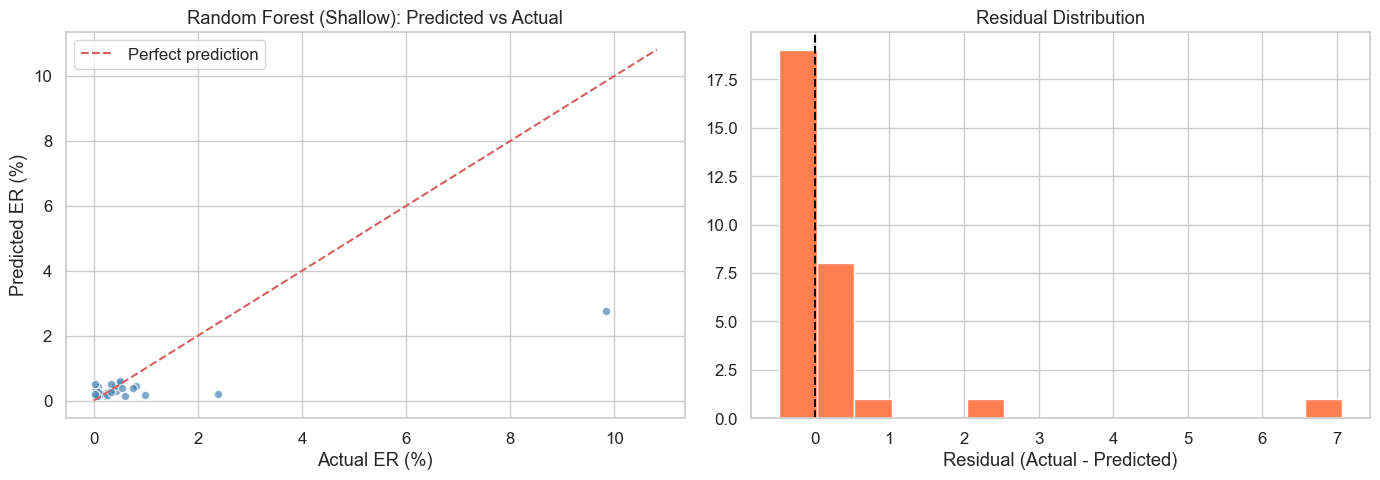

In [51]:
# ============================================================
# 6.2  Regression — Best Model Visualization
# ============================================================
best_reg_name = min(all_reg_results, key=lambda k: all_reg_results[k]["metrics"]["MAE"])
best_reg_result = all_reg_results[best_reg_name]
print(f"\n🏆 Best Regression Model: {best_reg_name}")
print(f"   Test MAE: {best_reg_result['metrics']['MAE']:.4f}")
print(f"   Test R²:  {best_reg_result['metrics']['R²']:.4f}")

if best_reg_name == "Stacking (Reg)":
    final_reg_model = reg_stacking_model
else:
    final_reg_model = best_reg_models[best_reg_name]

# Predicted vs Actual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

y_pred = best_reg_result["y_pred"]
y_actual = best_reg_result["y_actual"]

axes[0].scatter(y_actual, y_pred, alpha=0.7, color="steelblue", edgecolors="white")
max_val = max(y_actual.max(), y_pred.max()) * 1.1
axes[0].plot([0, max_val], [0, max_val], "r--", label="Perfect prediction")
axes[0].set_xlabel("Actual ER (%)")
axes[0].set_ylabel("Predicted ER (%)")
axes[0].set_title(f"{best_reg_name}: Predicted vs Actual")
axes[0].legend()

residuals = y_actual - y_pred
axes[1].hist(residuals, bins=15, color="coral", edgecolor="white")
axes[1].axvline(0, color="black", ls="--")
axes[1].set_xlabel("Residual (Actual - Predicted)")
axes[1].set_title("Residual Distribution")

plt.tight_layout()
plt.savefig(f"{config.MODEL_OUTPUT_DIR}/evaluation_regression.png", dpi=150)
plt.show()

In [52]:
# ============================================================
# 6.3  Classification — Test Set Evaluation
# ============================================================
print("\n" + "=" * 60)
print("📊 CLASSIFICATION HEAD — Test Set Results")
print("=" * 60)

all_clf_results = {}

for name, model in {**best_clf_models, "Stacking (Clf)": clf_stacking_model}.items():
    y_pred_cls = model.predict(X_test)
    acc = accuracy_score(y_test_cls, y_pred_cls)
    f1 = f1_score(y_test_cls, y_pred_cls, average="macro", zero_division=0)
    all_clf_results[name] = {"y_pred": y_pred_cls, "acc": acc, "f1": f1}
    print(f"\n📊 {name} — Accuracy: {acc:.4f}, F1 (macro): {f1:.4f}")

best_clf_result_name = max(all_clf_results, key=lambda k: all_clf_results[k]["f1"])
best_clf_result = all_clf_results[best_clf_result_name]
print(f"\n🏆 Best Classifier: {best_clf_result_name}")
print(f"   Accuracy: {best_clf_result['acc']:.4f}")
print(f"   F1 (macro): {best_clf_result['f1']:.4f}")

if best_clf_result_name == "Stacking (Clf)":
    final_clf_model = clf_stacking_model
else:
    final_clf_model = best_clf_models[best_clf_result_name]


📊 CLASSIFICATION HEAD — Test Set Results

📊 Gradient Boosting — Accuracy: 0.9667, F1 (macro): 0.6608

📊 LightGBM — Accuracy: 0.9333, F1 (macro): 0.6548

📊 Stacking (Clf) — Accuracy: 0.9667, F1 (macro): 0.6608

🏆 Best Classifier: Gradient Boosting
   Accuracy: 0.9667
   F1 (macro): 0.6608


📊 Engagement Classification Report:
              precision    recall  f1-score   support

     Average       0.00      0.00      0.00         1
        High       1.00      1.00      1.00         1
         Low       0.97      1.00      0.98        28

    accuracy                           0.97        30
   macro avg       0.66      0.67      0.66        30
weighted avg       0.93      0.97      0.95        30


📊 Regression-Derived Classification (for comparison):
              precision    recall  f1-score   support

     Average       0.00      0.00      0.00         1
        High       0.00      0.00      0.00         1
         Low       0.97      1.00      0.98        28

    accuracy                           0.93        30
   macro avg       0.32      0.33      0.33        30
weighted avg       0.90      0.93      0.92        30



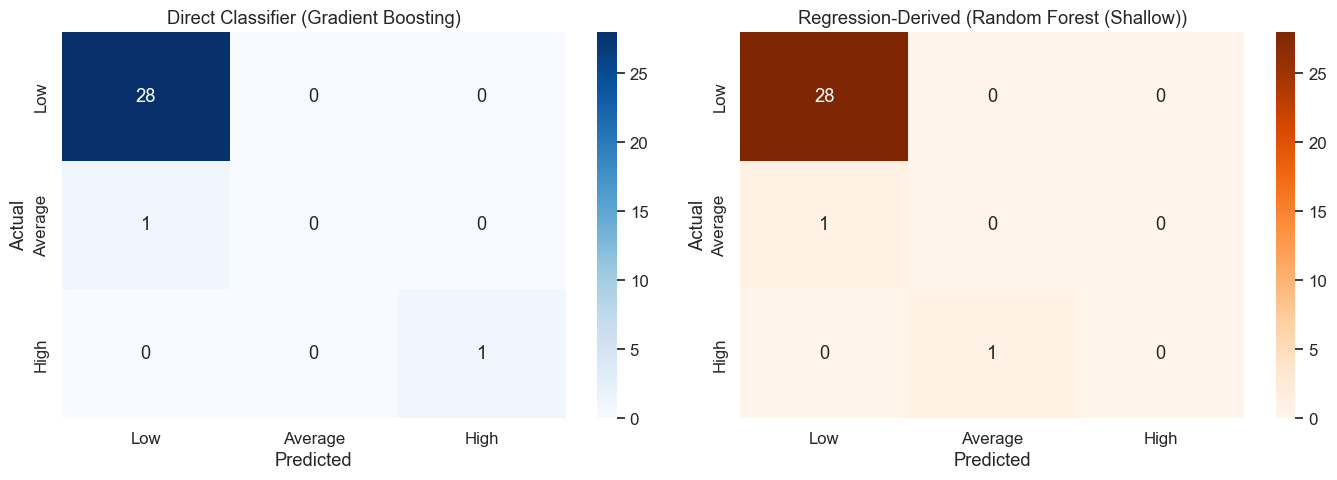

In [53]:
# ============================================================
# 6.4  Classification Report & Confusion Matrix
# ============================================================
y_pred_labels = label_encoder.inverse_transform(best_clf_result["y_pred"])
y_test_labels = label_encoder.inverse_transform(y_test_cls)

print("📊 Engagement Classification Report:")
print(classification_report(y_test_labels, y_pred_labels, zero_division=0))

# Also show regression-derived classification for comparison
reg_pred_classes = [classify_engagement(v) for v in best_reg_result["y_pred"]]
reg_actual_classes = [classify_engagement(v) for v in best_reg_result["y_actual"]]
print("\n📊 Regression-Derived Classification (for comparison):")
print(classification_report(reg_actual_classes, reg_pred_classes, zero_division=0))

# Confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Direct classifier
cm_cls = confusion_matrix(y_test_labels, y_pred_labels, labels=["Low", "Average", "High"])
sns.heatmap(cm_cls, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Low", "Average", "High"],
            yticklabels=["Low", "Average", "High"], ax=axes[0])
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].set_title(f"Direct Classifier ({best_clf_result_name})")

# Regression-derived
cm_reg = confusion_matrix(reg_actual_classes, reg_pred_classes, labels=["Low", "Average", "High"])
sns.heatmap(cm_reg, annot=True, fmt="d", cmap="Oranges",
            xticklabels=["Low", "Average", "High"],
            yticklabels=["Low", "Average", "High"], ax=axes[1])
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
axes[1].set_title(f"Regression-Derived ({best_reg_name})")

plt.tight_layout()
plt.savefig(f"{config.MODEL_OUTPUT_DIR}/confusion_matrix_comparison.png", dpi=150)
plt.show()

🔍 Computing SHAP values for model explainability...


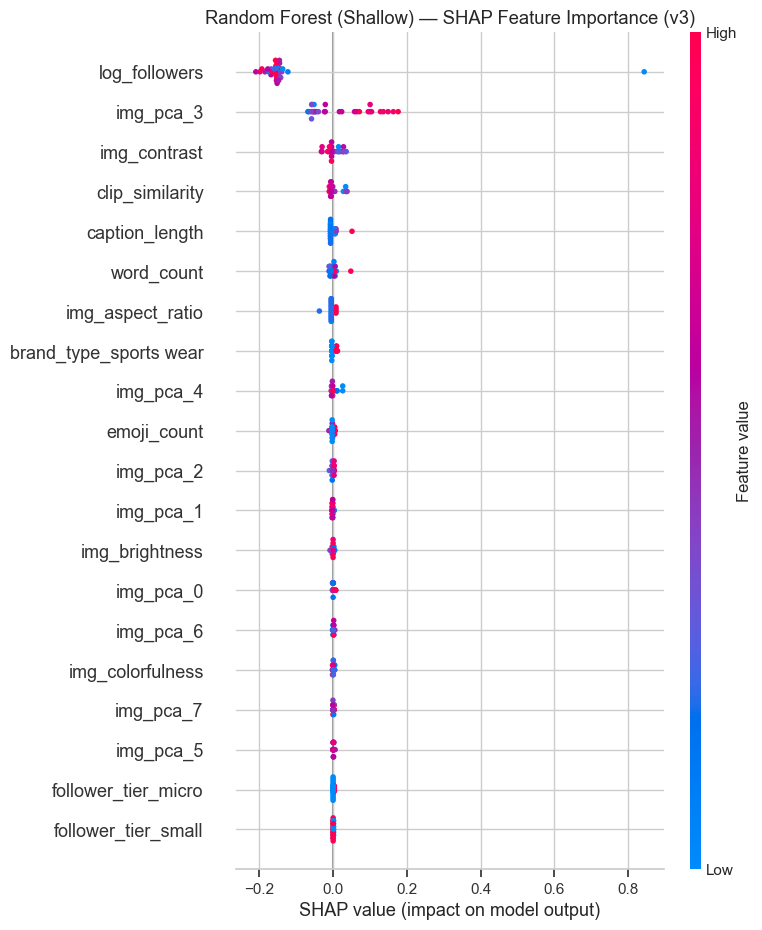

In [54]:
# ============================================================
# 6.5  SHAP Feature Importance (Explainability)
# ============================================================
print("🔍 Computing SHAP values for model explainability...")

# Use the best regression model for SHAP (more interpretable)
if best_reg_name != "Stacking (Reg)":
    best_pipeline = best_reg_models[best_reg_name]
    X_train_processed = best_pipeline.named_steps["preprocessor"].transform(X_train)
    X_test_processed = best_pipeline.named_steps["preprocessor"].transform(X_test)
    model_only = best_pipeline.named_steps["model"]

    # Get feature names after preprocessing
    ohe = best_pipeline.named_steps["preprocessor"].named_transformers_["categorical"]
    cat_names = ohe.get_feature_names_out(CATEGORICAL_FEATURES).tolist()
    all_feature_names = NUMERIC_FEATURES + BINARY_FEATURES + cat_names

    if hasattr(model_only, "feature_importances_"):
        explainer = shap.TreeExplainer(model_only)
    else:
        explainer = shap.KernelExplainer(model_only.predict, X_train_processed[:50])

    shap_values = explainer.shap_values(X_test_processed)

    fig, ax = plt.subplots(figsize=(10, 8))
    shap.summary_plot(
        shap_values,
        X_test_processed,
        feature_names=all_feature_names,
        show=False,
        max_display=20,
    )
    plt.title(f"{best_reg_name} — SHAP Feature Importance (v3)")
    plt.tight_layout()
    plt.savefig(f"{config.MODEL_OUTPUT_DIR}/shap_importance.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("   SHAP for Stacking ensemble — using KernelExplainer (slower)...")
    explainer = shap.KernelExplainer(final_reg_model.predict, X_train.iloc[:30])
    shap_values = explainer.shap_values(X_test.iloc[:20])
    shap.summary_plot(shap_values, X_test.iloc[:20], show=True)

In [55]:
# ============================================================
# 6.6  Prediction Confidence Indicator
# ============================================================
from sklearn.neighbors import NearestNeighbors

class ConfidenceEstimator:
    """Estimate prediction confidence based on proximity to training data."""

    def __init__(self, k: int = 5):
        self.k = k
        self.nn = NearestNeighbors(n_neighbors=k)
        self._fitted = False

    def fit(self, X_train_processed: np.ndarray):
        self.nn.fit(X_train_processed)
        dists, _ = self.nn.kneighbors(X_train_processed)
        self.train_mean_dists = dists.mean(axis=1)
        self._fitted = True
        return self

    def predict_confidence(self, X_processed: np.ndarray) -> List[str]:
        """Return confidence labels: High / Moderate / Low."""
        dists, _ = self.nn.kneighbors(X_processed)
        mean_dists = dists.mean(axis=1)

        p50 = np.percentile(self.train_mean_dists, 50)
        p85 = np.percentile(self.train_mean_dists, 85)

        labels = []
        for d in mean_dists:
            if d <= p50:
                labels.append("High")
            elif d <= p85:
                labels.append("Moderate")
            else:
                labels.append("Low")
        return labels


if best_reg_name != "Stacking (Reg)":
    confidence_est = ConfidenceEstimator(k=5)
    confidence_est.fit(X_train_processed)

    test_confidence = confidence_est.predict_confidence(X_test_processed)
    print("\n🎯 Prediction Confidence on Test Set:")
    from collections import Counter
    print(Counter(test_confidence))
else:
    print("⏭️ Confidence estimation for stacking — see export section.")


🎯 Prediction Confidence on Test Set:
Counter({'Moderate': 18, 'Low': 11, 'High': 1})


---
## 7. Export — Serialize Model for Streamlit Deployment

In [56]:
# ============================================================
# 7.1  Retrain best models on ALL data for production
# ============================================================
print("🔄 Retraining best models on full dataset for deployment...")

# Regression
if best_reg_name != "Stacking (Reg)":
    production_reg_model = best_reg_models[best_reg_name]
else:
    production_reg_model = reg_stacking_model
production_reg_model.fit(X, y_reg)
print(f"✅ Regression: {best_reg_name} retrained on all {len(X)} samples.")

# Classification
if best_clf_result_name != "Stacking (Clf)":
    production_clf_model = best_clf_models[best_clf_result_name]
else:
    production_clf_model = clf_stacking_model
production_clf_model.fit(X, y_class)
print(f"✅ Classification: {best_clf_result_name} retrained on all {len(X)} samples.")

🔄 Retraining best models on full dataset for deployment...
✅ Regression: Random Forest (Shallow) retrained on all 148 samples.
✅ Classification: Gradient Boosting retrained on all 148 samples.


In [57]:
# ============================================================
# 7.2  Save all artifacts for Streamlit
# ============================================================
artifacts_to_save = {
    # Regression head
    "reg_model": production_reg_model,
    "reg_model_name": best_reg_name,
    # Classification head
    "clf_model": production_clf_model,
    "clf_model_name": best_clf_result_name,
    "label_encoder": label_encoder,
    # Config
    "config": {
        "log_transform_target": config.LOG_TRANSFORM_TARGET,
        "er_high_threshold": config.ER_HIGH_THRESHOLD,
        "er_avg_threshold": config.ER_AVG_THRESHOLD,
        "feature_order": ALL_FEATURES,
        "numeric_features": NUMERIC_FEATURES,
        "binary_features": BINARY_FEATURES,
        "categorical_features": CATEGORICAL_FEATURES,
        "image_pca_components": N_IMAGE_COMPONENTS if USE_IMAGE_FEATURES else 0,
        "use_image_features": USE_IMAGE_FEATURES,
        "clip_model": config.CLIP_MODEL,
        "clip_pretrained": config.CLIP_PRETRAINED,
        "n_augment_views": config.N_AUGMENT_VIEWS,
    },
}

# Save PCA if used
if USE_IMAGE_FEATURES:
    artifacts_to_save["image_pca"] = pca

# Save confidence estimator
if best_reg_name != "Stacking (Reg)":
    artifacts_to_save["confidence_estimator"] = confidence_est

# Serialize
model_path = os.path.join(config.MODEL_OUTPUT_DIR, "adsavant_model_v3.pkl")
joblib.dump(artifacts_to_save, model_path)

file_size_mb = os.path.getsize(model_path) / (1024 * 1024)
print(f"\n💾 Model saved to: {model_path}")
print(f"   File size: {file_size_mb:.1f} MB")


💾 Model saved to: ./artifacts\adsavant_model_v3.pkl
   File size: 0.6 MB


In [58]:
# ============================================================
# 7.3  Inference Helper (for Streamlit integration)
# ============================================================
def predict_engagement(
    caption: str,
    brand_type: str,
    followers: int,
    image: Optional[Image.Image] = None,
) -> dict:
    """End-to-end prediction function for Streamlit.

    Args:
        caption: Post caption text
        brand_type: One of 'sports wear', 'casual wear', 'ethnic wear'
        followers: Brand's follower count
        image: Optional PIL Image for visual features

    Returns:
        dict with predicted_er, classification (direct + regression-derived), confidence
    """
    artifacts = joblib.load(model_path)
    reg_model = artifacts["reg_model"]
    clf_model = artifacts["clf_model"]
    le = artifacts["label_encoder"]
    cfg = artifacts["config"]

    # Extract text features
    text_df = pd.DataFrame({"caption": [caption]})
    text_feats = TextFeatureExtractor.extract(text_df)

    # Metadata features
    log_followers = np.log1p(followers)
    follower_tier = (
        "nano" if followers <= 5000
        else "micro" if followers <= 20000
        else "small" if followers <= 80000
        else "medium" if followers <= 150000
        else "large"
    )

    # Image features (CLIP with TTA)
    if cfg["use_image_features"] and image is not None:
        # CLIP embedding with TTA
        clip_emb = clip_extractor.extract_single(image, use_tta=True)
        clip_pca = artifacts["image_pca"].transform(clip_emb.reshape(1, -1))
        img_feats = {f"img_pca_{i}": clip_pca[0, i] for i in range(cfg["image_pca_components"])}

        # CLIP image-caption similarity
        img_feats["clip_similarity"] = clip_extractor.image_caption_similarity(image, caption)

        # Image metadata
        stat = ImageStat.Stat(image)
        img_feats["img_brightness"] = sum(stat.mean[:3]) / 3 / 255
        img_feats["img_contrast"] = sum(stat.stddev[:3]) / 3 / 255
        img_feats["img_colorfulness"] = (max(stat.mean[:3]) - min(stat.mean[:3])) / 255
        img_feats["img_aspect_ratio"] = image.width / image.height
        img_feats["img_is_square"] = int(abs(image.width - image.height) < 20)
        img_feats["img_dominant_warm"] = int(stat.mean[0] > stat.mean[2])
    else:
        img_feats = {f"img_pca_{i}": 0.0 for i in range(cfg["image_pca_components"])}
        img_feats["clip_similarity"] = 0.0
        img_feats["img_brightness"] = 0.0
        img_feats["img_contrast"] = 0.0
        img_feats["img_colorfulness"] = 0.0
        img_feats["img_aspect_ratio"] = 1.0
        img_feats["img_is_square"] = 1
        img_feats["img_dominant_warm"] = 0

    # Assemble feature row
    feature_row = {
        **text_feats.iloc[0].to_dict(),
        "log_followers": log_followers,
        "brand_type": brand_type.lower().strip(),
        "follower_tier": follower_tier,
        **img_feats,
    }

    input_df = pd.DataFrame([feature_row])[cfg["feature_order"]]

    # --- Regression prediction ---
    reg_prediction = reg_model.predict(input_df)[0]
    if cfg["log_transform_target"]:
        predicted_er = np.expm1(reg_prediction)
    else:
        predicted_er = reg_prediction
    predicted_er = max(0.0, predicted_er)
    reg_classification = classify_engagement(predicted_er)

    # --- Direct classification prediction ---
    clf_prediction = clf_model.predict(input_df)[0]
    direct_classification = le.inverse_transform([clf_prediction])[0]

    return {
        "predicted_engagement_rate": round(predicted_er, 4),
        "regression_classification": reg_classification,
        "direct_classification": direct_classification,
        "confidence": "Moderate",  # Simplified for demo
    }


# Quick test
test_result = predict_engagement(
    caption="New summer collection dropping tomorrow! Link in bio 🔥",
    brand_type="casual wear",
    followers=50000,
)
print("\n🧪 Test Prediction:")
for k, v in test_result.items():
    print(f"   {k}: {v}")


🧪 Test Prediction:
   predicted_engagement_rate: 0.1856
   regression_classification: Low
   direct_classification: Low
   confidence: Moderate


In [59]:
# ============================================================
# 7.4  Download artifacts from Colab
# ============================================================
# Uncomment to download:
# from google.colab import files
# files.download(model_path)

print("\n" + "=" * 60)
print("✅ AdSavant ML Pipeline v3 (Enhanced) Complete!")
print("=" * 60)
print(f"\nArtifacts saved in: {config.MODEL_OUTPUT_DIR}/")
print("  - adsavant_model_v3.pkl       (dual-head model + CLIP PCA + config)")
print("  - eda_*.png                   (EDA visualizations)")
print("  - evaluation_regression.png   (regression accuracy)")
print("  - confusion_matrix_comparison.png (classifier vs regression)")
print("  - shap_importance.png         (feature importance)")
print("\n📈 v3 Improvements Summary:")
print("  - CLIP embeddings (512D) replace ResNet50 (2048D)")
print("  - Multi-crop TTA (5 views averaged per image)")
print("  - CLIP image-caption similarity feature")
print("  - Image metadata: brightness, contrast, colorfulness, aspect ratio")
print("  - Expanded text features: hashtags, CTA, sentiment")
print("  - Dual-head: regression + classification with SMOTE")
print("  - LightGBM + SVR added to model zoo")
print("\nNext steps:")
print("  1. Download adsavant_model_v3.pkl")
print("  2. Update Streamlit app to use predict_engagement() with dual outputs")
print("  3. Collect more data to improve accuracy (target: 500+ posts)")


✅ AdSavant ML Pipeline v3 (Enhanced) Complete!

Artifacts saved in: ./artifacts/
  - adsavant_model_v3.pkl       (dual-head model + CLIP PCA + config)
  - eda_*.png                   (EDA visualizations)
  - evaluation_regression.png   (regression accuracy)
  - confusion_matrix_comparison.png (classifier vs regression)
  - shap_importance.png         (feature importance)

📈 v3 Improvements Summary:
  - CLIP embeddings (512D) replace ResNet50 (2048D)
  - Multi-crop TTA (5 views averaged per image)
  - CLIP image-caption similarity feature
  - Image metadata: brightness, contrast, colorfulness, aspect ratio
  - Expanded text features: hashtags, CTA, sentiment
  - Dual-head: regression + classification with SMOTE
  - LightGBM + SVR added to model zoo

Next steps:
  1. Download adsavant_model_v3.pkl
  2. Update Streamlit app to use predict_engagement() with dual outputs
  3. Collect more data to improve accuracy (target: 500+ posts)
